# **Machine Learning Workflow for DAC Surrogate Modelling**


 # **1.0. Preparing Data**

In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import scipy
import seaborn as sns
import shap
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline as make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import json

In [2]:
#Reading in the CSV file that contains simulation results
df_sim = pd.read_csv("DAC_simulation_results.csv")
print("df_sim type:", type(df_sim))
print("df_sim shape:", df_sim.shape)
df_sim.head()
df_sim.tail(20)
df_sim.sample(50)

df_sim type: <class 'pandas.core.frame.DataFrame'>
df_sim shape: (1100, 20)


,caco3_flow_rate [kmol/hr],calciner_temp [Deg C],pellet_moisture_frac,air_mol_flow_rate [kmol/hr],RH_air,DAC_column_height [m],pellet_diameter [mm],DAC_ambient_temp [Deg C],e_voidage,sim_index,Simulation_status,Failure_reason,Heat_duty[cal/sec],Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],SCM_conversion_fraction,Ca(OH)2_conversion,mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],DAC_inlet_press[atm]
218,16.782432,896.755259,0.453470,8530.772696,0.431106,3.390327,5.056943,22.431550,0.420881,218.0,Success,NaN,2.470331e+05,2509.16060,33.883462,0.009938,0.001748,129.933354,128.642124,1.315869
393,22.912494,896.864303,0.178330,8971.111281,0.275604,7.120934,1.567158,18.945545,0.373503,393.0,Success,NaN,3.372844e+05,12120.25530,36.716326,0.085909,0.011070,129.933354,118.770971,3.086369
876,71.235744,941.744016,0.228651,7095.964826,0.536577,7.801880,3.083930,29.047888,0.385536,876.0,Success,NaN,1.072206e+06,8007.87819,122.892430,0.081819,0.003391,129.933354,119.302399,2.197021
92,13.301801,911.695255,0.482159,7228.084471,0.522985,9.830819,5.528519,42.366356,0.437477,92.0,Failure,"(-2147352567, 'Exception occurred.', (14, 'VAS...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
594,15.128433,923.340978,0.181455,8225.084035,0.436790,3.374747,1.342465,31.536792,0.355645,594.0,Success,NaN,2.256490e+05,10671.16130,24.367110,0.061818,0.012064,129.933354,121.901089,2.748116
705,85.522179,892.947925,0.498884,8759.100275,0.140226,1.083679,2.577640,30.415549,0.414052,705.0,Success,NaN,1.256471e+06,1525.04191,173.428765,0.006301,0.000218,129.933354,129.114628,1.190424
51,38.281401,910.150596,0.337532,8732.825410,0.618326,8.997089,3.783183,16.318657,0.362369,51.0,Success,NaN,5.672659e+05,8782.35508,73.475690,0.067754,0.005225,129.933354,121.129818,2.348228
11,32.121472,935.495896,0.496032,8626.789327,0.313113,3.194537,1.546741,20.878654,0.372884,11.0,Success,NaN,4.819929e+05,8215.76157,65.136595,0.042573,0.003913,129.933354,124.401720,2.236901
500,22.530190,910.920635,0.149565,7417.344735,0.670814,6.568566,4.066311,29.613062,0.421113,500.0,Success,NaN,3.339873e+05,4680.91106,34.312802,0.040604,0.005321,129.933354,124.657547,1.625742
1041,22.724336,898.133354,0.198056,7933.277834,0.510205,2.173488,3.130830,42.490943,0.366620,1041.0,Success,NaN,3.347266e+05,4168.63076,37.564163,0.018302,0.002378,129.933354,127.555375,1.548394


# 1.1. Inpsecting data

In [3]:
df_sim.shape

(1100, 20)

In [4]:
df_sim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   caco3_flow_rate [kmol/hr]              1100 non-null   float64
 1   calciner_temp [Deg C]                  1100 non-null   float64
 2   pellet_moisture_frac                   1100 non-null   float64
 3   air_mol_flow_rate [kmol/hr]            1100 non-null   float64
 4   RH_air                                 1100 non-null   float64
 5   DAC_column_height [m]                  1100 non-null   float64
 6   pellet_diameter [mm]                   1100 non-null   float64
 7   DAC_ambient_temp [Deg C]               1100 non-null   float64
 8   e_voidage                              1100 non-null   float64
 9   sim_index                              1100 non-null   float64
 10  Simulation_status                      1100 non-null   object 
 11  Fail

In [5]:
#Checking for null values
df_sim.isnull().sum()

caco3_flow_rate [kmol/hr]                   0
calciner_temp [Deg C]                       0
pellet_moisture_frac                        0
air_mol_flow_rate [kmol/hr]                 0
RH_air                                      0
DAC_column_height [m]                       0
pellet_diameter [mm]                        0
DAC_ambient_temp [Deg C]                    0
e_voidage                                   0
sim_index                                   0
Simulation_status                           0
Failure_reason                           1022
Heat_duty[cal/sec]                         78
Brake_power[kW]                            78
calcium_hydroxide_pellet[kmol_per_hr]      78
SCM_conversion_fraction                    78
Ca(OH)2_conversion                         78
mass_flow_co2_in[kg/hr]                    78
mass_flow_co2_out[kg/hr]                   78
DAC_inlet_press[atm]                       78
dtype: int64

In [6]:
#Check the coount of null data
null_ser = df_sim.isnull().mean() * 100
null_ser.sort_values(ascending=False)

Failure_reason                           92.909091
DAC_inlet_press[atm]                      7.090909
mass_flow_co2_out[kg/hr]                  7.090909
mass_flow_co2_in[kg/hr]                   7.090909
Ca(OH)2_conversion                        7.090909
SCM_conversion_fraction                   7.090909
calcium_hydroxide_pellet[kmol_per_hr]     7.090909
Brake_power[kW]                           7.090909
Heat_duty[cal/sec]                        7.090909
calciner_temp [Deg C]                     0.000000
caco3_flow_rate [kmol/hr]                 0.000000
sim_index                                 0.000000
e_voidage                                 0.000000
DAC_ambient_temp [Deg C]                  0.000000
pellet_diameter [mm]                      0.000000
DAC_column_height [m]                     0.000000
RH_air                                    0.000000
air_mol_flow_rate [kmol/hr]               0.000000
pellet_moisture_frac                      0.000000
Simulation_status              

In [7]:
#inspecting the columns
df_sim.columns
#Removing whitespace
df_sim.columns = df_sim.columns.str.replace(" ", "")
df_sim.head()

,caco3_flow_rate[kmol/hr],calciner_temp[DegC],pellet_moisture_frac,air_mol_flow_rate[kmol/hr],RH_air,DAC_column_height[m],pellet_diameter[mm],DAC_ambient_temp[DegC],e_voidage,sim_index,Simulation_status,Failure_reason,Heat_duty[cal/sec],Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],SCM_conversion_fraction,Ca(OH)2_conversion,mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],DAC_inlet_press[atm]
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079,0.0,Success,NaN,1.453011e+06,3315.32380,197.732350,0.065231,0.001975,129.933354,121.457616,1.425452
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176,1.0,Success,NaN,4.797141e+05,1585.60372,61.085258,0.018301,0.001693,129.933354,127.555456,1.197886
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412,2.0,Success,NaN,9.938685e+05,1093.61784,133.214233,0.023755,0.001056,129.933354,126.846790,1.138224
3,5.255308,916.227948,0.082039,8304.100432,0.103660,9.760061,4.125589,21.887194,0.418892,3.0,Failure,"(-2147352567, 'Exception occurred.', (14, 'VAS...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470,4.0,Success,NaN,1.460315e+06,6795.42600,191.346494,0.067884,0.002024,129.933354,121.113005,1.974501


In [8]:
#Checking for duplicates
df_sim.duplicated().sum()

np.int64(0)

In [9]:
#create a capture efficiency columnn from SCM conversion
df_sim["capture_efficiency[%]"] = df_sim["SCM_conversion_fraction"] * 100
#Create a calcium hydroxide pellet flow rate column
df_sim.head()

,caco3_flow_rate[kmol/hr],calciner_temp[DegC],pellet_moisture_frac,air_mol_flow_rate[kmol/hr],RH_air,DAC_column_height[m],pellet_diameter[mm],DAC_ambient_temp[DegC],e_voidage,sim_index,...,Failure_reason,Heat_duty[cal/sec],Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],SCM_conversion_fraction,Ca(OH)2_conversion,mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],DAC_inlet_press[atm],capture_efficiency[%]
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079,0.0,...,NaN,1.453011e+06,3315.32380,197.732350,0.065231,0.001975,129.933354,121.457616,1.425452,6.523143
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176,1.0,...,NaN,4.797141e+05,1585.60372,61.085258,0.018301,0.001693,129.933354,127.555456,1.197886,1.830091
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412,2.0,...,NaN,9.938685e+05,1093.61784,133.214233,0.023755,0.001056,129.933354,126.846790,1.138224,2.375498
3,5.255308,916.227948,0.082039,8304.100432,0.103660,9.760061,4.125589,21.887194,0.418892,3.0,...,"(-2147352567, 'Exception occurred.', (14, 'VAS...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470,4.0,...,NaN,1.460315e+06,6795.42600,191.346494,0.067884,0.002024,129.933354,121.113005,1.974501,6.788364


## **2.0. Exploratory Data Analysis (EDA) And Feature Engineering**

In [10]:
#Getting a statistical overview of data
df_sim.describe()

,caco3_flow_rate[kmol/hr],calciner_temp[DegC],pellet_moisture_frac,air_mol_flow_rate[kmol/hr],RH_air,DAC_column_height[m],pellet_diameter[mm],DAC_ambient_temp[DegC],e_voidage,sim_index,Heat_duty[cal/sec],Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],SCM_conversion_fraction,Ca(OH)2_conversion,mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],DAC_inlet_press[atm],capture_efficiency[%]
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1.022000e+03,1022.000000,1022.000000,1022.000000,1022.000000,1.022000e+03,1022.000000,1022.000000,1022.000000
mean,52.499675,919.999024,0.274999,8000.023948,0.500014,5.500058,3.500016,29.999998,0.400000,549.500000,8.276897e+05,5689.075152,97.518048,0.061963,0.003783,1.299334e+02,121.882326,1.838565,6.196275
std,27.436942,17.328275,0.129965,577.601110,0.231046,2.599274,1.444004,8.663690,0.028879,317.686953,3.846605e+05,3064.812600,47.304893,0.068403,0.003971,2.871998e-12,8.887871,0.557903,6.840330
min,5.065444,890.017678,0.050103,7000.657660,0.100165,1.000661,1.004260,15.024729,0.350026,0.000000,9.528923e+04,601.906769,9.387038,0.002866,0.000108,1.299334e+02,33.622757,1.080748,0.286624
25%,28.786545,905.011176,0.162446,7500.660896,0.300390,3.249713,2.251078,22.496573,0.375059,274.750000,5.006344e+05,3424.415530,59.029759,0.021831,0.001346,1.299334e+02,120.130369,1.440766,2.183150
50%,52.521677,919.986637,0.274988,8000.311384,0.500032,5.498137,3.500283,30.000050,0.399967,549.500000,8.302167e+05,5209.523615,96.145416,0.040166,0.002423,1.299334e+02,124.714397,1.708415,4.016642
75%,76.216443,935.000324,0.387472,8499.839981,0.699990,7.746763,4.748493,37.492606,0.425014,824.250000,1.159914e+06,7481.864170,132.980512,0.075446,0.004664,1.299334e+02,127.096715,2.098390,7.544626
max,99.938586,949.947814,0.499891,8999.303640,0.899780,9.992005,5.995540,44.975387,0.449964,1099.000000,1.497330e+06,18045.795600,201.831131,0.741231,0.031118,1.299334e+02,129.560934,4.786643,74.123075


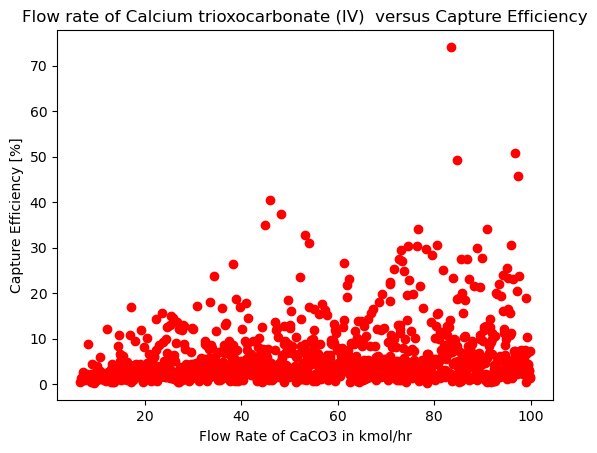

In [11]:
#Plotting visualizations of the various 
plt.scatter(df_sim["caco3_flow_rate[kmol/hr]"], df_sim["capture_efficiency[%]"], color="red") 
plt.xlabel("Flow Rate of CaCO3 in kmol/hr")
plt.ylabel("Capture Efficiency [%]")

plt.title("Flow rate of Calcium trioxocarbonate (IV)  versus Capture Efficiency");

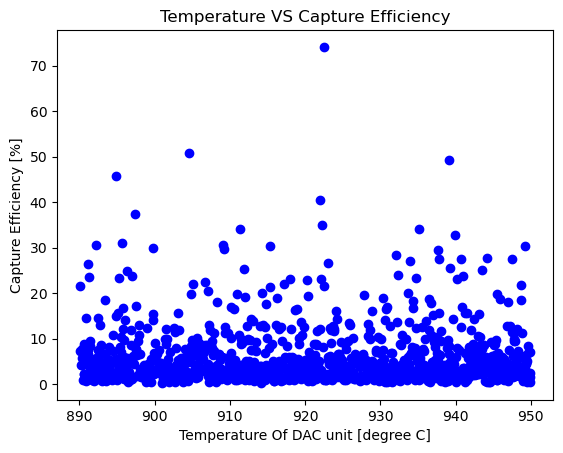

In [12]:
#Plotting visualizations of the various 
plt.scatter(df_sim["calciner_temp[DegC]"], df_sim["capture_efficiency[%]"], color="blue") 
plt.xlabel("Temperature Of DAC unit [degree C]")
plt.ylabel("Capture Efficiency [%]")

plt.title("Temperature VS Capture Efficiency");

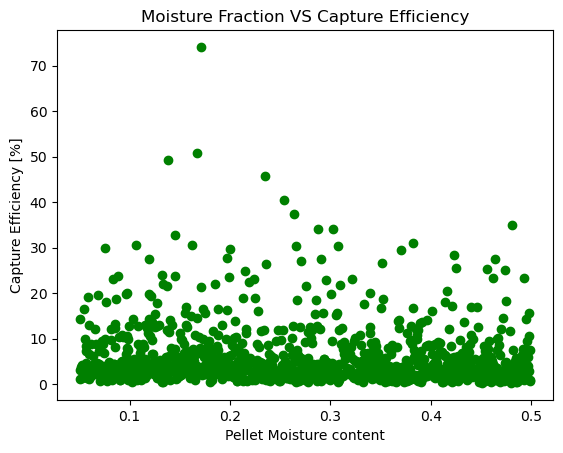

In [13]:
#Plotting visualizations of the various 
plt.scatter(df_sim["pellet_moisture_frac"], df_sim["capture_efficiency[%]"], color="green") 
plt.xlabel("Pellet Moisture content")
plt.ylabel("Capture Efficiency [%]")

plt.title("Moisture Fraction VS Capture Efficiency");

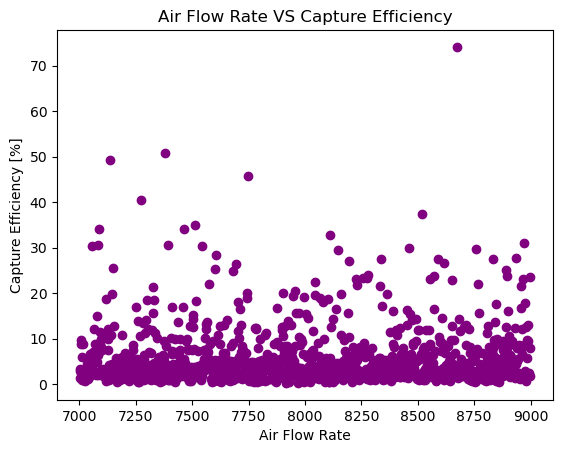

In [14]:
#Plotting visualizations of the various 
plt.scatter(df_sim["air_mol_flow_rate[kmol/hr]"], df_sim["capture_efficiency[%]"], color="purple") 
plt.xlabel("Air Flow Rate")
plt.ylabel("Capture Efficiency [%]")

plt.title("Air Flow Rate VS Capture Efficiency");

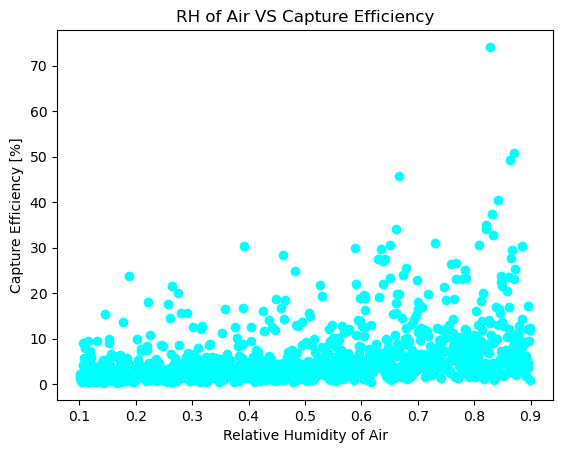

In [15]:
#Plotting visualizations of the various 
plt.scatter(df_sim["RH_air"], df_sim["capture_efficiency[%]"], color="cyan") 
plt.xlabel("Relative Humidity of Air")
plt.ylabel("Capture Efficiency [%]")

plt.title("RH of Air VS Capture Efficiency");

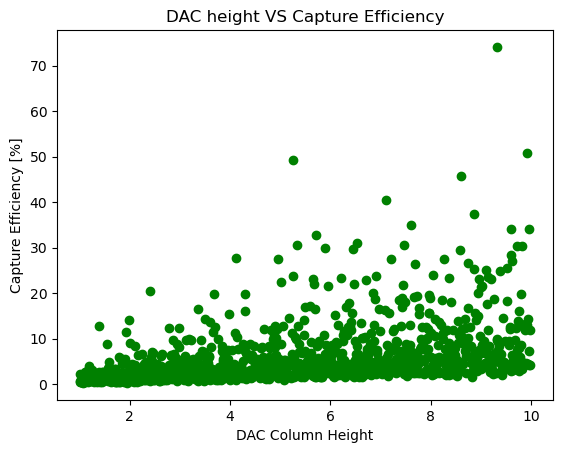

In [16]:
#Plotting visualizations of the various 
plt.scatter(df_sim["DAC_column_height[m]"], df_sim["capture_efficiency[%]"], color="green") 
plt.xlabel("DAC Column Height")
plt.ylabel("Capture Efficiency [%]")

plt.title("DAC height VS Capture Efficiency");

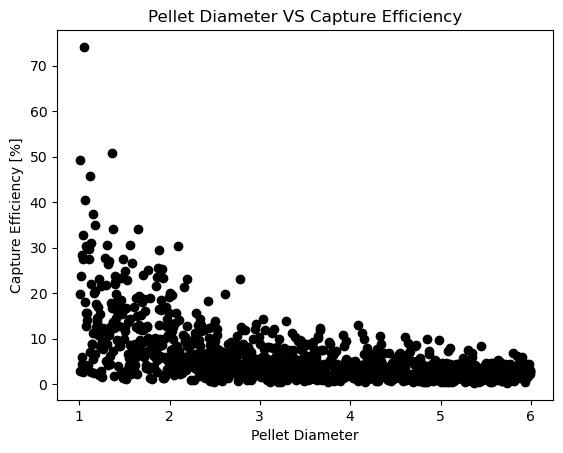

In [17]:
#Plotting visualizations of the various 
plt.scatter(df_sim["pellet_diameter[mm]"], df_sim["capture_efficiency[%]"], color="black") 
plt.xlabel("Pellet Diameter")
plt.ylabel("Capture Efficiency [%]")

plt.title("Pellet Diameter VS Capture Efficiency");

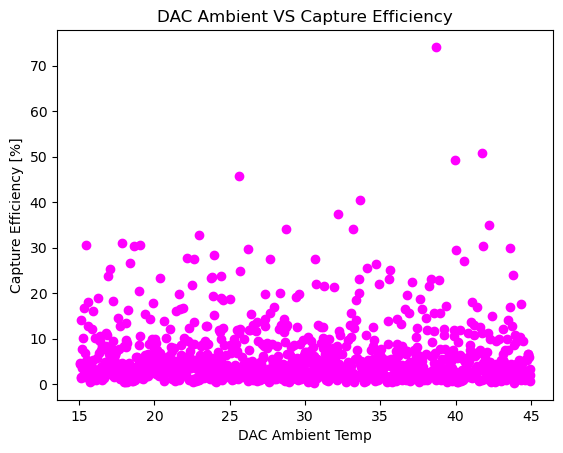

In [18]:
#Plotting visualizations of the various 
plt.scatter(df_sim["DAC_ambient_temp[DegC]"], df_sim["capture_efficiency[%]"], color="magenta") 
plt.xlabel("DAC Ambient Temp")
plt.ylabel("Capture Efficiency [%]")

plt.title("DAC Ambient VS Capture Efficiency");

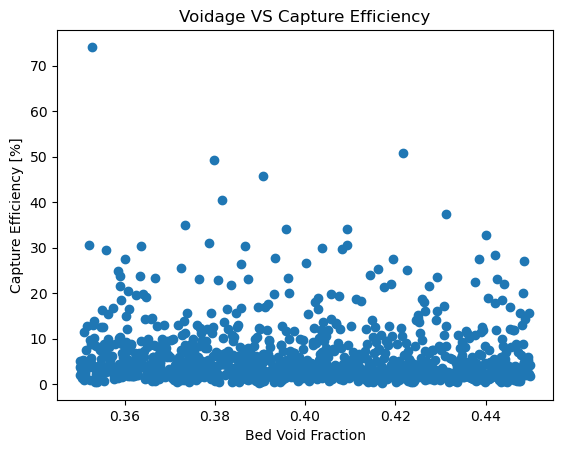

In [19]:
#Plotting visualizations of the various 
plt.scatter(df_sim["e_voidage"], df_sim["capture_efficiency[%]"]) 
plt.xlabel("Bed Void Fraction")
plt.ylabel("Capture Efficiency [%]")

plt.title("Voidage VS Capture Efficiency");

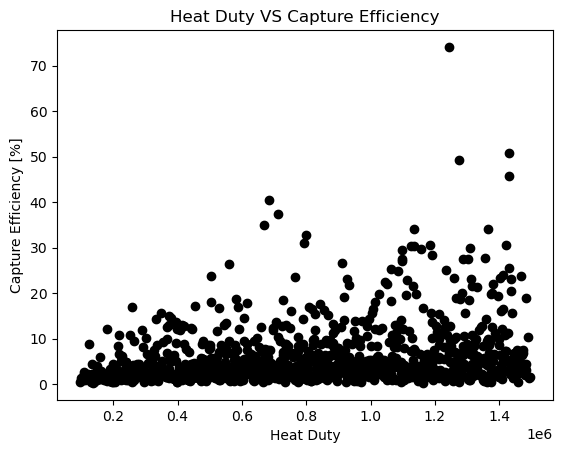

In [20]:
#Plotting visualizations of the various 
plt.scatter(abs(df_sim["Heat_duty[cal/sec]"]), df_sim["capture_efficiency[%]"], color="black") 
plt.xlabel("Heat Duty")
plt.ylabel("Capture Efficiency [%]")

plt.title("Heat Duty VS Capture Efficiency");

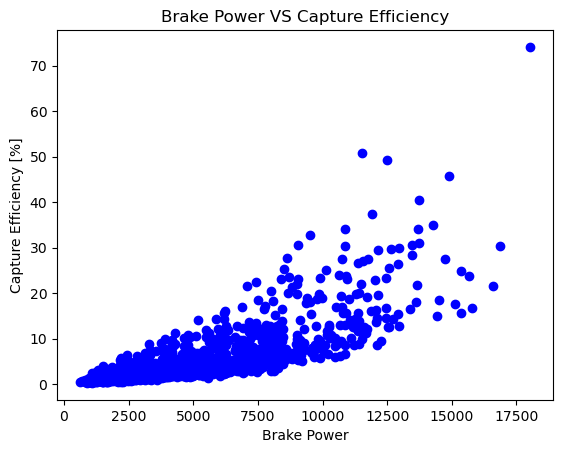

In [21]:
#Plotting visualizations of the various 
plt.scatter(abs(df_sim["Brake_power[kW]"]), df_sim["capture_efficiency[%]"], color="blue") 
plt.xlabel("Brake Power")
plt.ylabel("Capture Efficiency [%]")

plt.title("Brake Power VS Capture Efficiency");

In [22]:
#investigating the failed simulations
df_sim.groupby("Simulation_status")["Failure_reason"].value_counts().to_frame()

count
Simulation_status Failure_reason                                           
Failure           (-2147352567, 'Exception occurred.', (14, 'VASe...     72
                  (-2147417851, 'The server threw an exception.',...      4
                  (-2147023170, 'The remote procedure call failed...      2

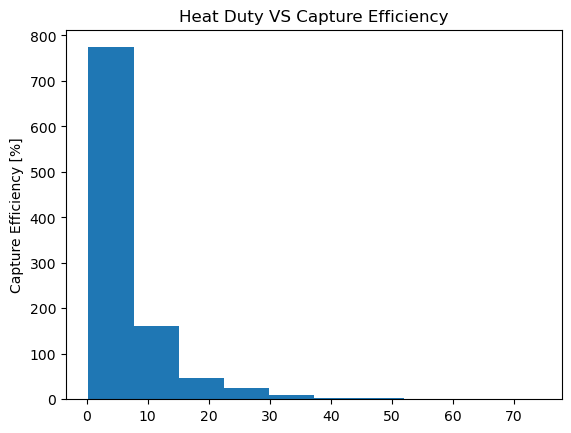

In [23]:
#Histogram plot of conversion
#Plotting visualizations of the various 
plt.hist(df_sim["capture_efficiency[%]"],) 

plt.ylabel("Capture Efficiency [%]")

plt.title("Heat Duty VS Capture Efficiency");

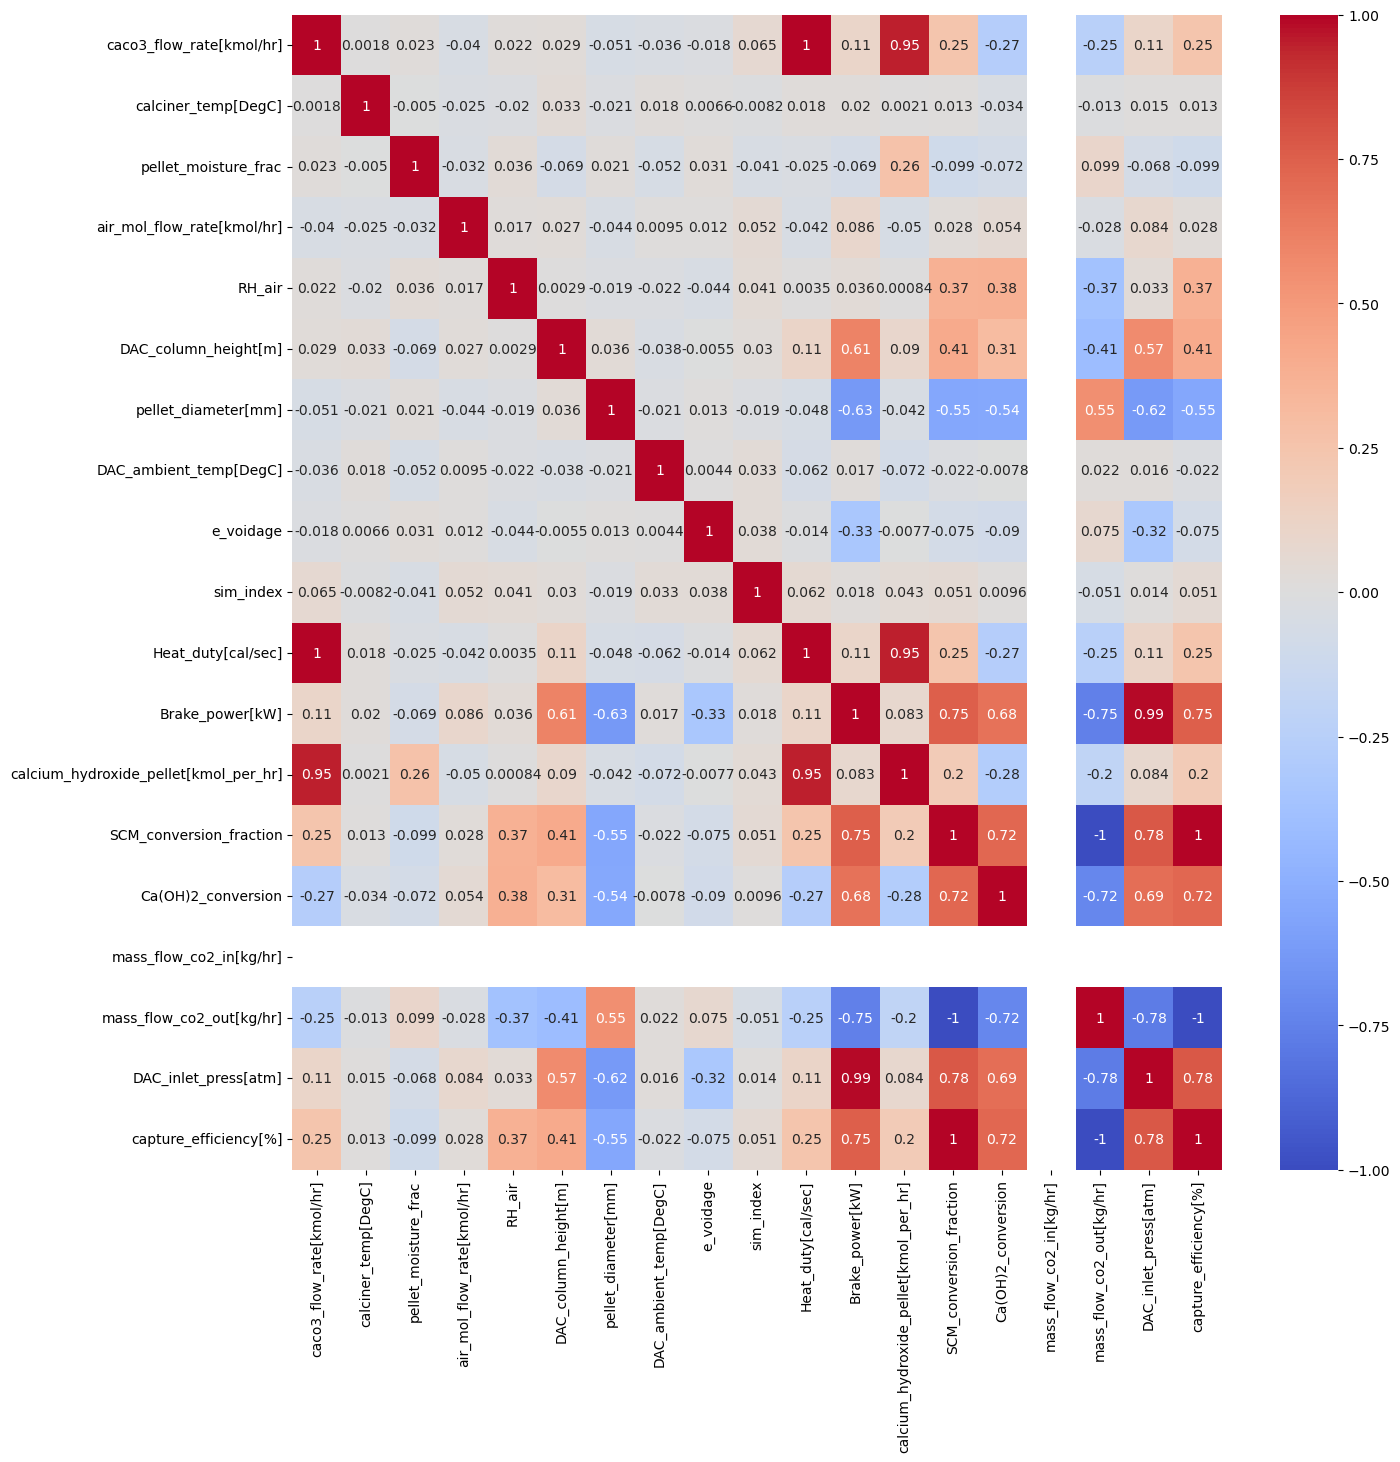

In [24]:
#correlation investigation
df_sim_corr = df_sim.select_dtypes(include='number').corr()
Fig, ax = plt.subplots(figsize=(15, 15))
sns.heatmap(df_sim_corr, annot=True, cmap="coolwarm", ax=ax);

In [25]:
df_sim.head()

,caco3_flow_rate[kmol/hr],calciner_temp[DegC],pellet_moisture_frac,air_mol_flow_rate[kmol/hr],RH_air,DAC_column_height[m],pellet_diameter[mm],DAC_ambient_temp[DegC],e_voidage,sim_index,...,Failure_reason,Heat_duty[cal/sec],Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],SCM_conversion_fraction,Ca(OH)2_conversion,mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],DAC_inlet_press[atm],capture_efficiency[%]
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079,0.0,...,NaN,1.453011e+06,3315.32380,197.732350,0.065231,0.001975,129.933354,121.457616,1.425452,6.523143
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176,1.0,...,NaN,4.797141e+05,1585.60372,61.085258,0.018301,0.001693,129.933354,127.555456,1.197886,1.830091
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412,2.0,...,NaN,9.938685e+05,1093.61784,133.214233,0.023755,0.001056,129.933354,126.846790,1.138224,2.375498
3,5.255308,916.227948,0.082039,8304.100432,0.103660,9.760061,4.125589,21.887194,0.418892,3.0,...,"(-2147352567, 'Exception occurred.', (14, 'VAS...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470,4.0,...,NaN,1.460315e+06,6795.42600,191.346494,0.067884,0.002024,129.933354,121.113005,1.974501,6.788364


In [26]:
#Dropping highly correlated features
df_sim = df_sim.drop(["DAC_inlet_press[atm]", "SCM_conversion_fraction", "Ca(OH)2_conversion"], axis="columns")

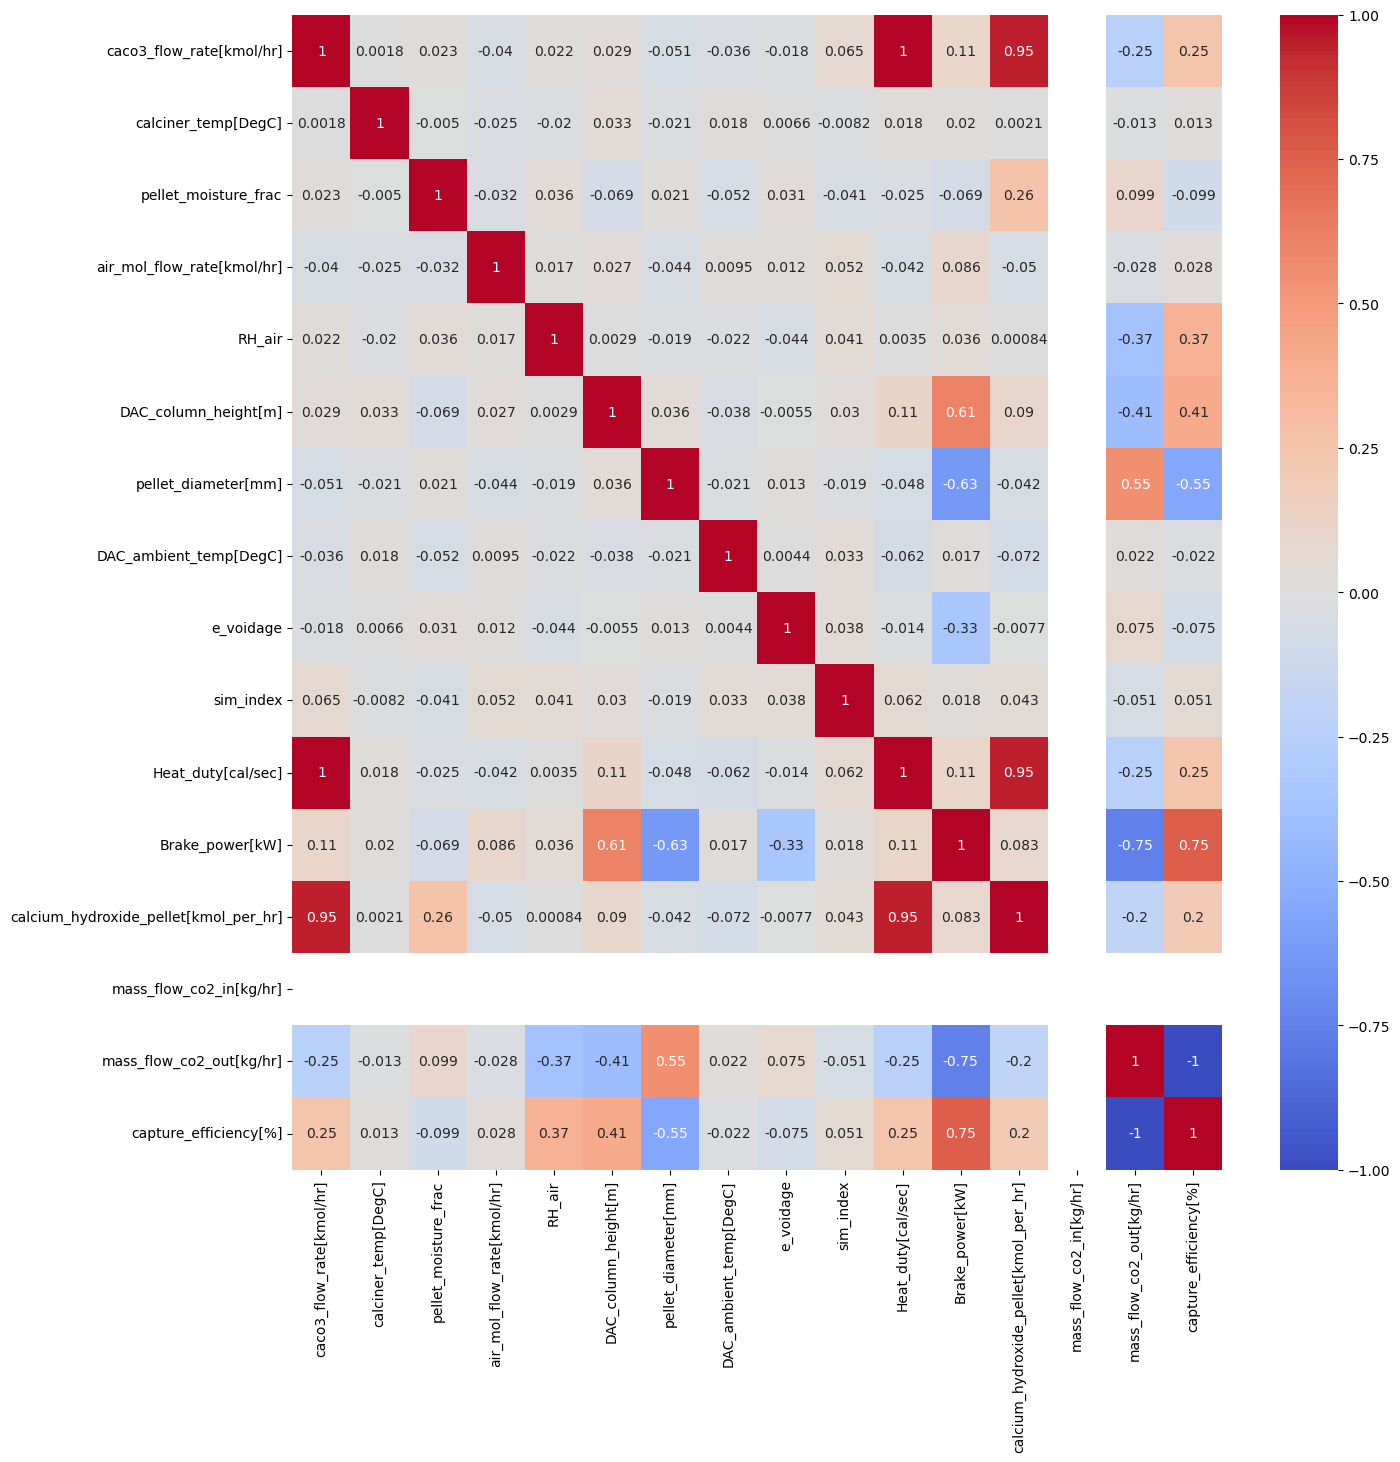

In [27]:
df_sim_corr = df_sim.select_dtypes(include='number').corr()
Fig, ax = plt.subplots(figsize=(15, 15))
sns.heatmap(df_sim_corr, annot=True, cmap="coolwarm", ax=ax);

In [28]:
#dropping columns with object type values
df_sim = df_sim.drop(["Failure_reason", "Simulation_status"], axis="columns")

In [29]:
#Converting the simulation index from float to int type
df_sim["sim_index"] = df_sim["sim_index"].astype(int)
#setting sim_index as the index of the df_sim dataframe
df_sim = df_sim.set_index("sim_index")

In [30]:
#Converting Cal/sec to KW
df_sim["Heat_duty[cal/sec]"] = abs(df_sim["Heat_duty[cal/sec]"] * 0.004184)
#renaming column to Heat_duty[KW]
df_sim= df_sim.rename(columns= {"Heat_duty[cal/sec]": "Heat_duty[KW]"})
df_sim.head()

,caco3_flow_rate[kmol/hr],calciner_temp[DegC],pellet_moisture_frac,air_mol_flow_rate[kmol/hr],RH_air,DAC_column_height[m],pellet_diameter[mm],DAC_ambient_temp[DegC],e_voidage,Heat_duty[KW],Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],capture_efficiency[%]
sim_index,,,,,,,,,,,,,,,
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079,6079.399185,3315.32380,197.732350,129.933354,121.457616,6.523143
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176,2007.123711,1585.60372,61.085258,129.933354,127.555456,1.830091
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412,4158.345681,1093.61784,133.214233,129.933354,126.846790,2.375498
3,5.255308,916.227948,0.082039,8304.100432,0.103660,9.760061,4.125589,21.887194,0.418892,NaN,NaN,NaN,NaN,NaN,NaN
4,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470,6109.959374,6795.42600,191.346494,129.933354,121.113005,6.788364


In [31]:
#Converting the power units to costs, to reflective value of power
df_sim["power_cost[$]"] = df_sim["Brake_power[kW]"] * 0.1778 + df_sim["Heat_duty[KW]"] * 0.05
#Calculating mass of CO2 captured
df_sim["mass_co2_captured[kg/hr]"] = df_sim["mass_flow_co2_in[kg/hr]"] - df_sim["mass_flow_co2_out[kg/hr]"]
#Calculating Specific Energy Cost per CO2 consumed
df_sim["SECC"] = df_sim["power_cost[$]"] / df_sim["mass_co2_captured[kg/hr]"]
df_sim  = df_sim.drop(columns=["Brake_power[kW]", "Heat_duty[KW]", "mass_co2_captured[kg/hr]", "power_cost[$]", "mass_flow_co2_in[kg/hr]", "mass_flow_co2_out[kg/hr]", "calcium_hydroxide_pellet[kmol_per_hr]"])

In [32]:
df_sim.head()

,caco3_flow_rate[kmol/hr],calciner_temp[DegC],pellet_moisture_frac,air_mol_flow_rate[kmol/hr],RH_air,DAC_column_height[m],pellet_diameter[mm],DAC_ambient_temp[DegC],e_voidage,capture_efficiency[%],SECC
sim_index,,,,,,,,,,,
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079,6.523143,105.410825
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176,1.830091,160.762374
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412,2.375498,130.359369
3,5.255308,916.227948,0.082039,8304.100432,0.103660,9.760061,4.125589,21.887194,0.418892,NaN,NaN
4,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470,6.788364,171.617326


In [33]:
df_sim.dropna(inplace=True)

In [34]:
df_sim.columns = df_sim.columns.str.replace("[", "_")
df_sim.columns = df_sim.columns.str.replace("]", "")

In [35]:
df_sim.head()

,caco3_flow_rate_kmol/hr,calciner_temp_DegC,pellet_moisture_frac,air_mol_flow_rate_kmol/hr,RH_air,DAC_column_height_m,pellet_diameter_mm,DAC_ambient_temp_DegC,e_voidage,capture_efficiency_%,SECC
sim_index,,,,,,,,,,,
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079,6.523143,105.410825
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176,1.830091,160.762374
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412,2.375498,130.359369
4,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470,6.788364,171.617326
5,98.462316,905.306138,0.112064,7753.304554,0.248262,2.872001,1.768148,41.269448,0.434394,3.421679,257.358216


In [36]:
df_sim.columns 

Index(['caco3_flow_rate_kmol/hr', 'calciner_temp_DegC', 'pellet_moisture_frac',
       'air_mol_flow_rate_kmol/hr', 'RH_air', 'DAC_column_height_m',
       'pellet_diameter_mm', 'DAC_ambient_temp_DegC', 'e_voidage',
       'capture_efficiency_%', 'SECC'],
      dtype='object')

In [37]:
#Save wrangled data
df_sim.to_csv("wrangled_DAC_simuation_results.csv", index=False, encoding="utf-8")

# **3.0. Split**

# 3.1 Split (for Efficiency Model)


**Feature Matrix**

In [38]:
#Feature Matrix 
X = df_sim.drop(columns=["SECC", "capture_efficiency_%"])
X.head()

,caco3_flow_rate_kmol/hr,calciner_temp_DegC,pellet_moisture_frac,air_mol_flow_rate_kmol/hr,RH_air,DAC_column_height_m,pellet_diameter_mm,DAC_ambient_temp_DegC,e_voidage
sim_index,,,,,,,,,
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412
4,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470
5,98.462316,905.306138,0.112064,7753.304554,0.248262,2.872001,1.768148,41.269448,0.434394


**Target Vector**

In [39]:
target = "capture_efficiency_%"
y = df_sim[target]
y.head()

sim_index
0    6.523143
1    1.830091
2    2.375498
4    6.788364
5    3.421679
Name: capture_efficiency_%, dtype: float64

**Train, Test split**

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42
)

In [41]:
#Validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train, 
    test_size = 0.2,
    random_state=42
)

In [42]:
#Using value counts to see if splitting worked
print("Train target vector distribution:")
print(y_train.value_counts(normalize=True))

print("Validation target vector distribution:")
print(y_val.value_counts(normalize=True))

print("Test target vector distribution:")
print(y_test.value_counts(normalize=True))


Train target vector distribution:
capture_efficiency_%
5.168783     0.001531
12.016126    0.001531
12.195457    0.001531
2.687119     0.001531
16.416114    0.001531
               ...   
1.356115     0.001531
12.937399    0.001531
3.778710     0.001531
12.425591    0.001531
0.808873     0.001531
Name: proportion, Length: 653, dtype: float64
Validation target vector distribution:
capture_efficiency_%
2.950204    0.006098
0.993763    0.006098
4.987708    0.006098
1.070945    0.006098
5.882841    0.006098
              ...   
1.385097    0.006098
1.745891    0.006098
6.958531    0.006098
1.064969    0.006098
6.775424    0.006098
Name: proportion, Length: 164, dtype: float64
Test target vector distribution:
capture_efficiency_%
7.244904     0.004878
9.752216     0.004878
2.378327     0.004878
5.573518     0.004878
1.737444     0.004878
               ...   
12.835870    0.004878
6.788364     0.004878
3.812066     0.004878
1.853439     0.004878
3.344314     0.004878
Name: proportion, Length

# 3.2. Model Buiding

In [43]:
efficiency_model= XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=50
)

In [44]:
eff_model_pipeline = make_pipeline([
    ("model", efficiency_model)
])

In [45]:
eff_model_pipeline.fit(
    X_train,
    y_train,
    model__eval_set=[(X_val, y_val)],
    model__verbose=False
)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8


In [46]:
#Check that the parameters were actually logged
print(efficiency_model.get_params())

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': 50, 'enable_categorical': False, 'eval_metric': 'rmse', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1000, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [47]:
#Calculate the performance metrics, rmse, r2
y_val_pred=eff_model_pipeline.predict(X_val)
print(y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 =  r2_score(y_val, y_val_pred)
print("Root mean squared error is:", rmse)
print("Standard deviation  of y_val:", np.std(y_val))
print("r2 score is:", r2)

[ 3.985361    5.289498    4.686214    5.943385    2.393295    1.7989093
  3.435398    1.3861159   6.4717517   8.316366   20.59172     3.0261223
  1.5771526   0.95974946  1.9481498  18.793175    4.2701454   4.2288413
 11.377169    5.595933   11.334659    2.6984422  21.066402   28.824633
 34.515724    3.21001     7.6458015   1.1902695   4.7632856   6.9522614
  2.6429095   6.5688634   5.623344    3.170952    3.1203227  12.024684
  6.378207    2.0988393   3.8725343  18.657986    3.3171635   1.0695132
  2.8156676   5.924538    2.8499212   2.0275714   3.511922   11.58696
  2.033942    2.6361039   4.518704   12.301066    1.5765935   7.393089
  5.3943853   1.6024241   1.8972315   8.135131    1.2756021   2.4213586
 10.287812    2.7597377   1.4866142   2.380032    5.5813804   0.9504245
  6.1701193  11.036141    3.017587   13.342443    8.933541    4.5562353
  0.80548704  3.5001237   4.3553233   8.436664    2.9146423  19.091452
  7.6974144  33.000973    3.8242745   2.1371286   1.1946439   5.990217

In [48]:
#Checking performance metrics on training data
y_train_pred= eff_model_pipeline.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(rmse_train)

r2_train =  r2_score(y_train, y_train_pred)

print(r2_train)

0.0007997827230581951
0.9999999831469274


In [49]:
#Print trining residuals
y_resid =  y_val - y_val_pred
print(y_resid)

sim_index
79     -1.035158
110     0.016025
1086    0.418056
453    -1.095500
266    -0.598855
          ...   
821     0.400299
896    -0.353386
1021   -1.091063
146     0.109679
51      0.526298
Name: capture_efficiency_%, Length: 164, dtype: float64


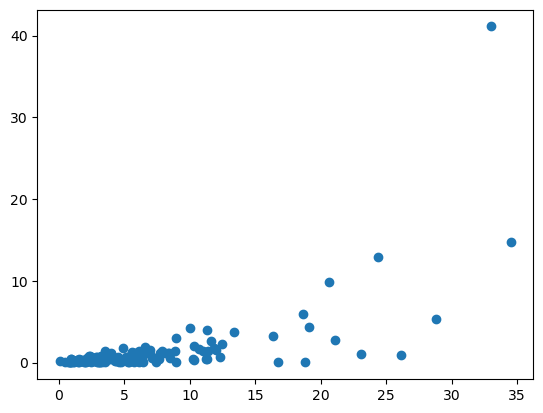

In [50]:
plt.scatter(y_val_pred, abs(y_resid))

In [51]:
#inspecting early stopping behavior to see if it worked
model = eff_model_pipeline.named_steps["model"]
print("Best number of iterations of model is:", model.best_iteration)
print("The model's best score is:", model.best_score)

Best number of iterations of model is: 879
The model's best score is: 3.838584846164468


# 3.3. Hyperparameter Tuning

In [52]:
#Combine training and validation set since we are using randomized search cv
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])
print("Length of full training data is:", len(y_train_full))

Length of full training data is: 817


In [53]:
efficiency_model= XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse"
)

eff_model_pipeline = make_pipeline([
    ("model", efficiency_model)
])

In [54]:
#Defining the range of hyper parameters
params_range = {
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__subsample": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0.5, 1, 5, 10, 11, 15],
}

In [55]:
#Cross Validation set up
search = RandomizedSearchCV(
    eff_model_pipeline,
    n_iter=30,
    param_distributions=params_range,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train_full, y_train_full)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.6, 0.8, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 3, ...], 'model__reg_alpha': [0, 0.01, ...], ...}"
,n_iter,30
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [56]:
#print the best parameters
print("The best parameters are:", search.best_params_)
print("The best rmse score:", -search.best_score_)

The best parameters are: {'model__subsample': 0.3, 'model__reg_lambda': 10, 'model__reg_alpha': 0, 'model__min_child_weight': 3, 'model__max_depth': 4, 'model__colsample_bytree': 1.0}
The best rmse score: 1.523469757819511


In [57]:
# Re training model on the best hyperparameters
best_hyperparams = search.best_params_

final_eff_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    max_depth=best_hyperparams["model__max_depth"],
    min_child_weight=best_hyperparams["model__min_child_weight"],
    subsample=best_hyperparams["model__subsample"],
    colsample_bytree=best_hyperparams["model__colsample_bytree"],
    reg_alpha=best_hyperparams["model__reg_alpha"],
    reg_lambda=best_hyperparams["model__reg_lambda"]
)

best_eff_model_pipeline = make_pipeline([
    ("final_model", final_eff_model)
])



best_eff_model_pipeline.fit(
    X_train_full,
    y_train_full,
    final_model__verbose=False
)


,steps,"[('final_model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0


In [58]:
#Calculate the performance metrics, rmse, r2
y_pred_test=best_eff_model_pipeline.predict(X_test)
print(y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 =  r2_score(y_test, y_pred_test)
print("Root mean squared error is:", rmse)
print("Standard deviation  of y_val:", np.std(y_test))
print("r2 score is:", r2)

[ 7.0657997   7.8535166   2.5023737   2.551976    3.4775598   4.0609794
 14.120797    3.5843353   9.600484    0.817717    1.5224513   3.0852535
  5.7806473   9.081114    4.595921    0.60385156 22.12642     2.1320994
  5.265946    3.258904    3.955415    1.7316933   5.046056    4.26651
  6.8083205   0.8609369   3.1723976   3.5414112   4.28768     0.71037567
  0.45162672 27.828178    2.9089026   2.0827968   7.9558167   1.004289
  6.3798113   2.8185503   6.237601    3.9748852   5.863889    3.0351722
  7.0552735   5.6612306   3.6936245  25.218029   22.695566    8.67345
 11.868745    0.98240703  2.2383547   5.8965545   7.6964192   3.8427534
  4.3854203   4.060161    2.091051    3.0926988   3.674175    2.3306582
 12.939715    1.5044478  15.591785    5.2025995   4.6440663   2.1498976
 12.468223    4.8688507   0.28341827 10.788092   10.365673   13.762183
  6.7464237   3.7443185   1.8679864   3.3919363   8.2286625   2.1527033
  2.0622773   2.5454636  13.13834     1.7044885   4.315473    1.14605

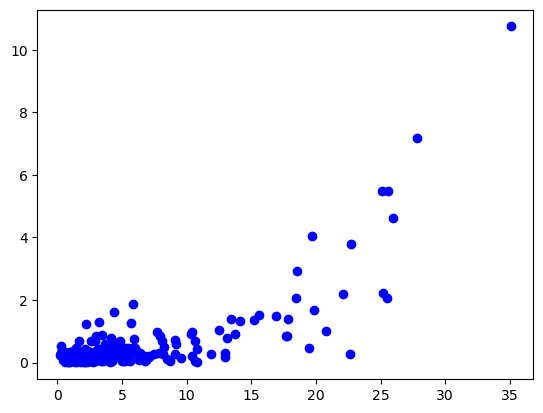

In [59]:
y_test_resid = y_test - y_pred_test
plt.scatter(y_pred_test, abs(y_test_resid), color="blue")

In [60]:
#Geting the feature importances
feature_importances = best_eff_model_pipeline.named_steps["final_model"].feature_importances_

In [61]:
odds_ratio = pd.Series(feature_importances, index=X_train_full.columns).sort_values()
odds_ratio

calciner_temp_DegC           0.011822
air_mol_flow_rate_kmol/hr    0.016857
DAC_ambient_temp_DegC        0.021050
pellet_moisture_frac         0.028299
e_voidage                    0.030474
caco3_flow_rate_kmol/hr      0.076597
RH_air                       0.172413
DAC_column_height_m          0.281596
pellet_diameter_mm           0.360894
dtype: float32

Text(0.5, 1.0, 'Feature Importances For Efficiency')

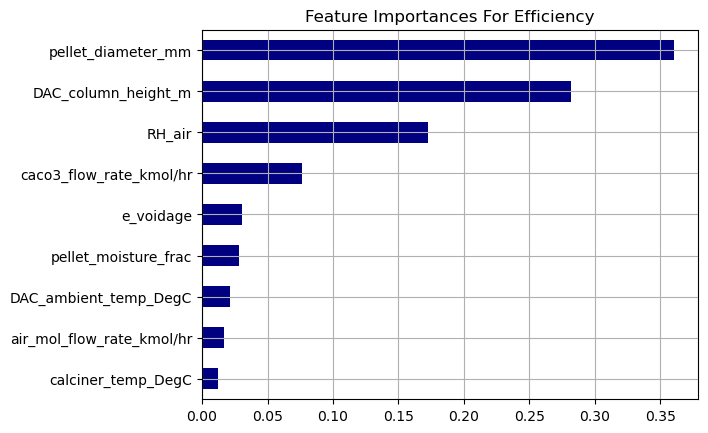

In [62]:
odds_ratio.plot(kind="barh", color="navy")
plt.grid(True)
plt.title("Feature Importances For Efficiency")

# 3.4. Save Efficiency (Conversion) Model

In [63]:
#Access the efficiency model from the pipeline
best_eff_model_pipeline.named_steps["final_model"].save_model("DAC_efficiency_XGBmodel.json")

# **4. Model Building for SECC**

# 4.1. Split

**Feature Matrix**

In [64]:
#Feature Matrix 
X = df_sim.drop(columns=["SECC", "capture_efficiency_%"])
X.head()

,caco3_flow_rate_kmol/hr,calciner_temp_DegC,pellet_moisture_frac,air_mol_flow_rate_kmol/hr,RH_air,DAC_column_height_m,pellet_diameter_mm,DAC_ambient_temp_DegC,e_voidage
sim_index,,,,,,,,,
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412
4,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470
5,98.462316,905.306138,0.112064,7753.304554,0.248262,2.872001,1.768148,41.269448,0.434394


In [65]:
target = "SECC"
y = df_sim[target]
y.head()

sim_index
0    105.410825
1    160.762374
2    130.359369
4    171.617326
5    257.358216
Name: SECC, dtype: float64

**Train, test, split**

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42
)

In [67]:
#Validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train, 
    test_size = 0.2,
    random_state=42
)

In [68]:
#Using value counts to see if splitting worked
print("Train target vector distribution:")
print(y_train.value_counts(normalize=True))

print("Validation target vector distribution:")
print(y_val.value_counts(normalize=True))

print("Test target vector distribution:")
print(y_test.value_counts(normalize=True))


Train target vector distribution:
SECC
188.363311    0.001531
109.343826    0.001531
117.661556    0.001531
274.488502    0.001531
109.136083    0.001531
                ...   
350.193717    0.001531
83.861796     0.001531
242.902019    0.001531
81.812283     0.001531
442.915316    0.001531
Name: proportion, Length: 653, dtype: float64
Validation target vector distribution:
SECC
269.514214    0.006098
385.530135    0.006098
167.902749    0.006098
502.604768    0.006098
241.908106    0.006098
                ...   
376.495128    0.006098
346.667355    0.006098
131.457018    0.006098
295.938265    0.006098
190.852263    0.006098
Name: proportion, Length: 164, dtype: float64
Test target vector distribution:
SECC
98.734035     0.004878
142.270323    0.004878
354.589975    0.004878
88.973907     0.004878
380.829793    0.004878
                ...   
76.646166     0.004878
171.617326    0.004878
156.952224    0.004878
350.482522    0.004878
347.392186    0.004878
Name: proportion, Length: 20

In [69]:
energy_model= XGBRegressor(
    n_estimators=1600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=50
)

In [70]:
energy_model_pipeline = make_pipeline([
    ("model", energy_model)
])

In [71]:
energy_model_pipeline.fit(
    X_train,
    y_train,
    model__eval_set=[(X_val, y_val)],
    model__verbose=False
)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8


In [72]:
#Check that the parameters were actually logged
print(energy_model.get_params())

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': 50, 'enable_categorical': False, 'eval_metric': 'rmse', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1600, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [73]:
#Calculate the performance metrics, rmse, r2
y_val_pred=energy_model_pipeline.predict(X_val)
print(y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 =  r2_score(y_val, y_val_pred)
print("Root mean squared error is:", rmse)
print("Standard deviation  of y_val:", np.std(y_val))
print("r2 score is:", r2)

[262.9735   123.24264  232.729    223.01315  414.0847   310.512
 341.4524   295.7092   144.7302   120.95518   72.05839  219.66354
 374.75052  521.12274  304.36304   86.38129  255.01143  130.61665
 113.20867  131.09323   89.48042  260.1439   153.52373   70.57064
  53.663666 279.99628   99.52701  401.0509   184.6647   122.816444
 208.17741  184.09717  172.7057   179.89647  226.59525   90.22562
 159.65724  337.85776  251.35771  141.23854  308.395    434.98547
 427.2209   141.82033  309.3738   275.49408  316.15936  100.13978
 319.75674  324.9523   251.59285  148.18706  357.83914  144.08562
 167.34546  318.78796  251.68198  147.218    292.15024  293.70334
 116.027916 285.6456   233.42172  209.32172  157.7878   549.79663
 278.16785  174.07327  170.36911   98.067856 160.0296   239.4931
 372.19937  296.33438  121.88559   97.031136 147.23764  102.98783
 153.15779   75.62778  239.97293  255.6854   418.25827  172.64989
 188.5517   168.34604  308.1985   292.2976   124.70416  150.09763
 351.60544  

In [74]:
#Checking performance metrics on training data
y_train_pred= energy_model_pipeline.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(rmse_train)

r2_train =  r2_score(y_train, y_train_pred)

print(r2_train)

0.01735428007495757
0.9999999808517146


In [75]:
#Print trining residuals
y_val_resid =  y_val - y_val_pred
print(y_val_resid)

sim_index
79       6.540703
110     -6.887859
1086   -28.178377
453      1.059224
266     12.391557
          ...    
821    -14.407063
896      1.104037
1021   -10.984331
146     -6.919767
51     -13.801500
Name: SECC, Length: 164, dtype: float64


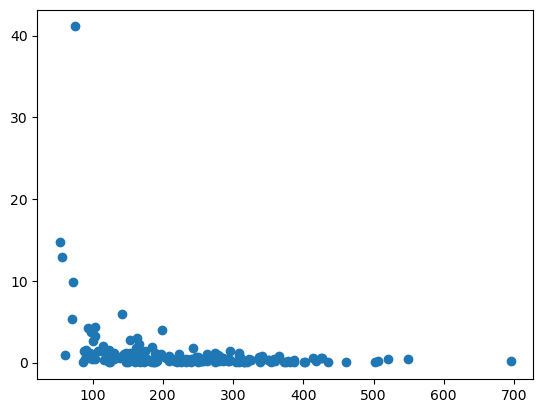

In [76]:
plt.scatter(y_val_pred, abs(y_resid))

In [77]:
#inspecting early stopping behavior to see if it worked
model = energy_model_pipeline.named_steps["model"]
print("Best number of iterations of model is:", model.best_iteration)
print("The model's best score is:", model.best_score)

Best number of iterations of model is: 869
The model's best score is: 45.24514130718792


# 4.2. Hyperparamater Tuning

In [78]:
#Combine training and validation set since we are using randomized search cv
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])
print("Length of full training data is:", len(y_train_full))
print(y_train_full)

Length of full training data is: 817
sim_index
1042    188.363311
139     194.592963
365     332.883615
98      130.497065
439     146.821431
           ...    
821      89.465000
896     156.493059
1021     79.208036
146     182.019304
51      190.852263
Name: SECC, Length: 817, dtype: float64


In [79]:
energy_model= XGBRegressor(
    n_estimators=1600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse"
)
energy_model_pipeline = make_pipeline([
    ("model", energy_model)
])

In [80]:
#Defining the range of hyper parameters
params_range = {
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__subsample": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0.5, 1, 5, 10, 11, 15],
}

In [81]:
#Cross Validation set up
search = RandomizedSearchCV(
    energy_model_pipeline,
    n_iter=30,
    param_distributions=params_range,
    scoring="r2",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train_full, y_train_full)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.6, 0.8, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 3, ...], 'model__reg_alpha': [0, 0.01, ...], ...}"
,n_iter,30
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [82]:
#print the best parameters
print("The best parameters are:", search.best_params_)
print("The best rmse score:", -search.best_score_)

The best parameters are: {'model__subsample': 0.4, 'model__reg_lambda': 1, 'model__reg_alpha': 0.01, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__colsample_bytree': 0.8}
The best rmse score: -0.953420219379511


In [83]:
# Re training model on the best hyperparameters
best_hyperparams = search.best_params_

final_energy_model = XGBRegressor(
    n_estimators=1600,
    learning_rate=0.03,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    max_depth=best_hyperparams["model__max_depth"],
    min_child_weight=best_hyperparams["model__min_child_weight"],
    subsample=best_hyperparams["model__subsample"],
    colsample_bytree=best_hyperparams["model__colsample_bytree"],
    reg_alpha=best_hyperparams["model__reg_alpha"],
    reg_lambda=best_hyperparams["model__reg_lambda"]
)

best_energy_model_pipeline = make_pipeline([
    ("final_energy_model", final_energy_model)
])



best_energy_model_pipeline.fit(
    X_train_full,
    y_train_full,
    final_energy_model__verbose=False
)


,steps,"[('final_energy_model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8


In [84]:
#Calculate the performance metrics, rmse, r2
y_pred_test=best_energy_model_pipeline.predict(X_test)
print(y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 =  r2_score(y_test, y_pred_test)
print("Root mean squared error is:", rmse)
print("Standard deviation  of y_val:", np.std(y_test))
print("r2 score is:", r2)

[110.10677  171.27927  375.84512  299.81064  190.72983  209.69617
 122.15111  247.45131  138.90411  456.3319   315.2789   236.47665
 144.23947  227.03606  171.8851   664.6707    82.581566 129.82489
 202.16121  395.4628   270.02386  385.58527  199.08978  274.34338
 166.3435   532.81573  215.3643   169.62183  235.55312  510.97617
 574.3325    62.678513 268.46118  113.69014  138.99565  418.78995
 132.0276   248.9609   202.00937  153.80626  249.25427  296.72662
 111.207634 191.72464  334.34747   62.57544   77.91408  176.19893
  95.94654  529.01953  269.44458  275.37286  239.34612  311.38342
 269.27875  288.972    261.81543  332.13077  176.37794  185.44177
 121.355125 295.9197    99.217514 233.97179  147.62326  292.8839
 140.63457  245.42683  601.97046  176.12173  125.99533   71.876144
 181.69897  164.00424  360.04965  276.27032  112.86449  318.6479
 413.96808  304.13144  101.86135  268.13278  139.36253  376.84497
 128.46387  227.30109  530.41364  219.01152  232.04613  119.998695
 111.93812

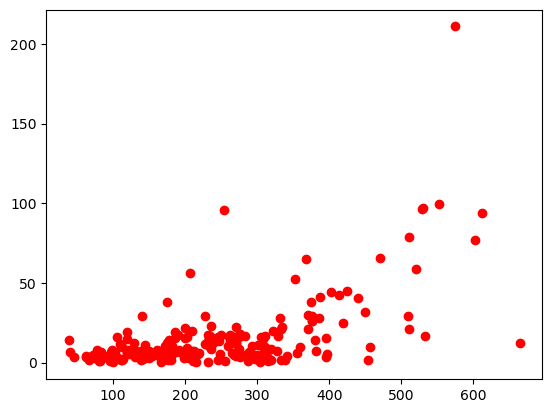

In [85]:
y_test_resid = y_test - y_pred_test
plt.scatter(y_pred_test, abs(y_test_resid), color="red")

In [86]:
print(y_test_resid)

sim_index
1065   -11.372738
520      6.510330
745     25.962500
33       4.951578
670     17.491237
          ...    
490      7.307854
777     17.368808
994     14.259138
607    -31.751853
859    -29.076991
Name: SECC, Length: 205, dtype: float64


In [87]:
#Geting the feature importances
feature_importances_en = best_energy_model_pipeline.named_steps["final_energy_model"].feature_importances_

In [88]:
odds_ratio_en = pd.Series(feature_importances_en, index=X_train_full.columns).sort_values()
odds_ratio_en

calciner_temp_DegC           0.011984
air_mol_flow_rate_kmol/hr    0.017651
DAC_ambient_temp_DegC        0.023299
pellet_moisture_frac         0.050320
e_voidage                    0.056776
caco3_flow_rate_kmol/hr      0.057336
DAC_column_height_m          0.165920
pellet_diameter_mm           0.217748
RH_air                       0.398965
dtype: float32

Text(0.5, 1.0, 'Feature Importances For SECC')

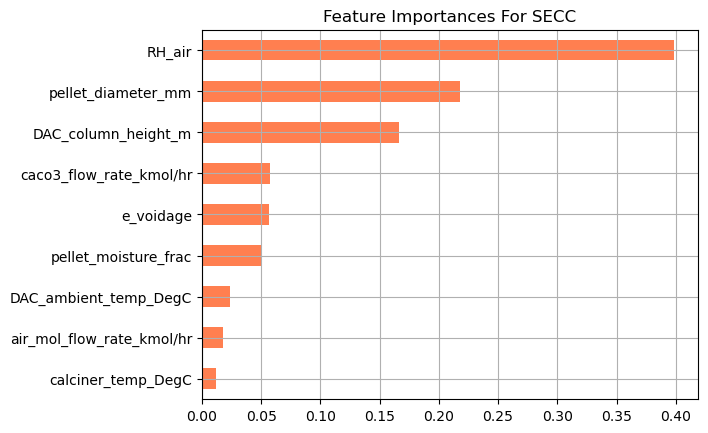

In [89]:
odds_ratio_en.plot(kind="barh", color="coral")
plt.grid(True)
plt.title("Feature Importances For SECC")

# Save Energy Model

In [90]:
best_energy_model_pipeline.named_steps["final_energy_model"].save_model("DAC_SECC_XGBmodel.json")